# Integrated Gradients for N-BEATS CO2 Forecasting

Run this notebook to explain the trained N-BEATS CO2 model from `N_BEATS.ipynb` using Integrated Gradients.

The first code cell runs the original N-BEATS notebook, so the trained `model`, test windows, feature names, and scaler are available here without changing the original file.


(1924653, 21)
(1924649, 9)
(186889, 9)
(186889, 9)
(186884, 10)
(186884, 10)
(186884, 10)
                        lower_bound   upper_bound  outlier_count  \
ens160_aqi            -5.000000e-01  3.500000e+00            0.0   
ens160_tvoc           -9.768571e+01  2.889048e+02            0.0   
bme688_gas_resistance  1.287263e+07  1.299140e+07            0.0   
bme688_pressure        9.849031e+01  1.018882e+02            0.0   
scd41_temperature      1.971432e+01  2.910343e+01            0.0   
scd41_humidity         8.847241e+00  6.352849e+01            0.0   
scd41_co2              2.501637e+02  7.448383e+02            0.0   
target_co2_15min       2.501637e+02  7.448383e+02            0.0   

                       outlier_percent  
ens160_aqi                         0.0  
ens160_tvoc                        0.0  
bme688_gas_resistance              0.0  
bme688_pressure                    0.0  
scd41_temperature                  0.0  
scd41_humidity                     0.0  
scd41_co2 

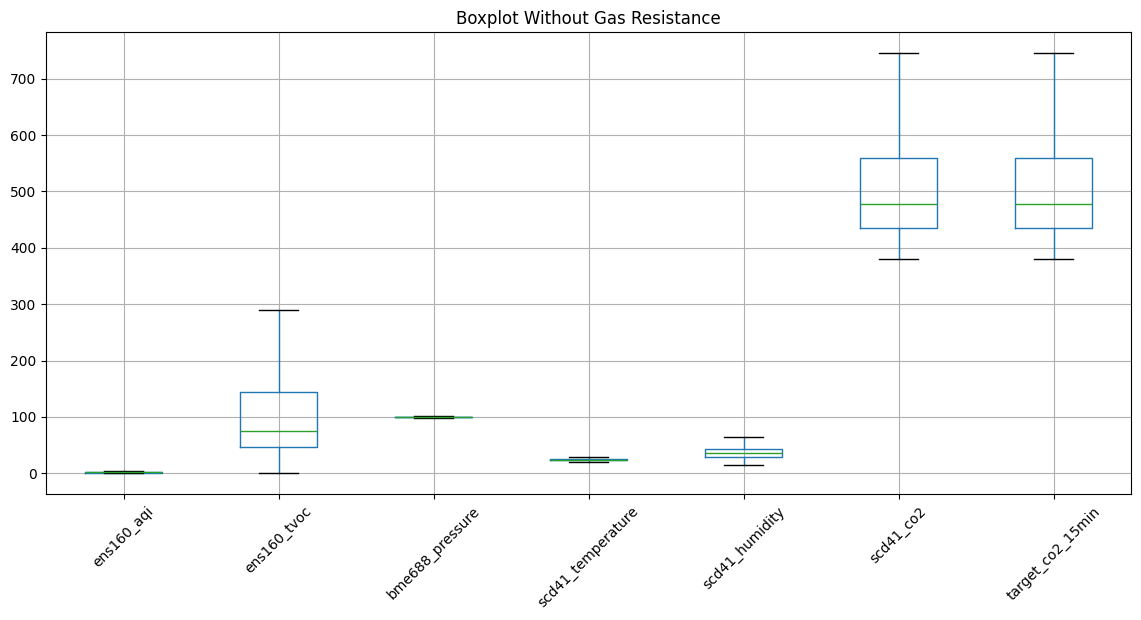

Train shape: (130816, 10)
Val shape: (28031, 10)
Test shape: (28037, 10)
Train percentage: 69.99850174439759
Val percentage: 14.999143853941483
Test percentage: 15.002354401660922

Rows per station:
            train   val  test
station_id                   
1           35269  7557  7559
2           13566  2907  2908
3           30913  6624  6625
4           30627  6563  6564
5           20441  4380  4381
Scaled X min/max: 0.0 1.0000000000000002
Scaled y min/max: 0.0 1.0000000000000002
X_train: (130516, 60, 8) y_train: (130516,)
X_val: (27731, 60, 8) y_val: (27731,)
X_test: (27737, 60, 8) y_test: (27737,)
Train batches: 2040
Val batches: 434
Test batches: 434
NBeats(
  (blocks): ModuleList(
    (0-1): 2 x NBeatsBlock(
      (fc): Sequential(
        (0): Linear(in_features=480, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=256, bias=True)
        (3): ReLU()
        (4): Linear(in_features=256, out_features=256, bias=True)
        (5

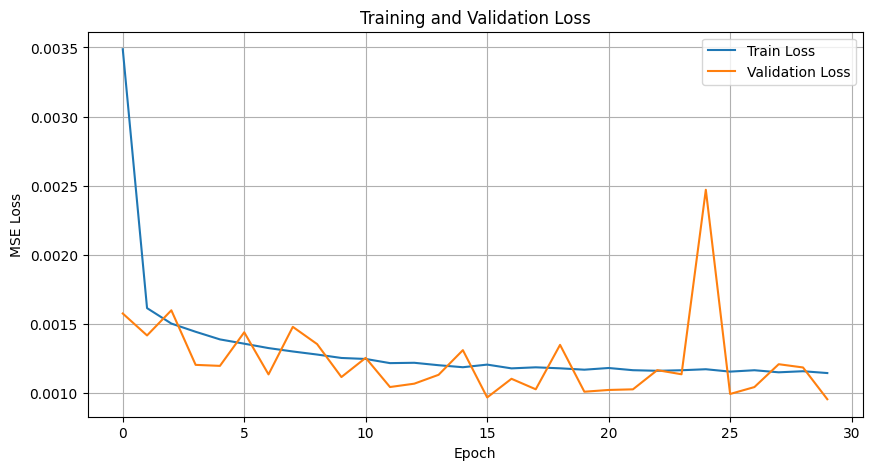

Metrics WITHOUT inverse scaling
MAE: 0.010203087702393532
MSE: 0.00046905121416784823
RMSE: 0.02165759022070203
R2: 0.994785726070404
Predictions shape: (27737, 1)
Actuals shape: (27737, 1)
Metrics WITH inverse scaling
Test MAE: 3.7275705337524414
Test MSE: 62.60517883300781
Test RMSE: 7.912343447614481
Test R2: 0.994785726070404


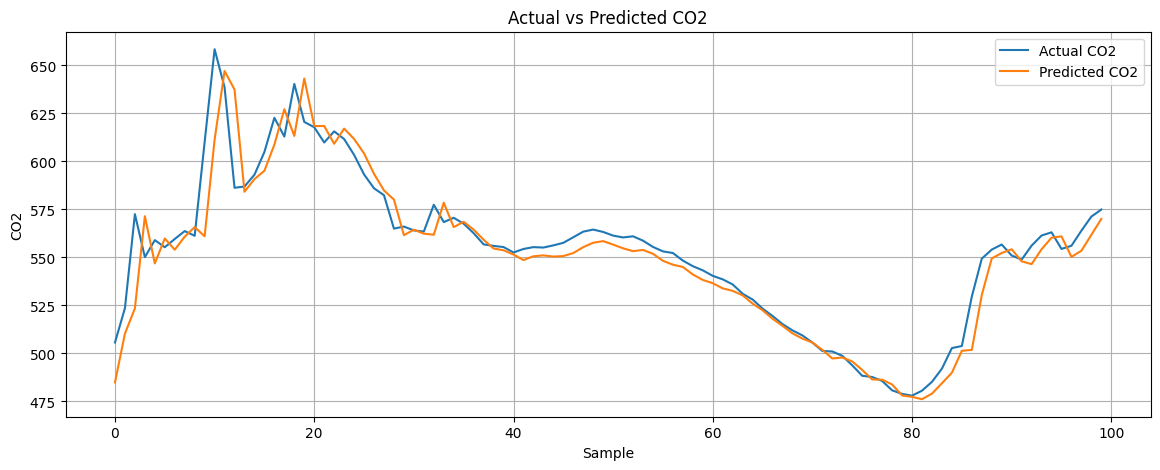

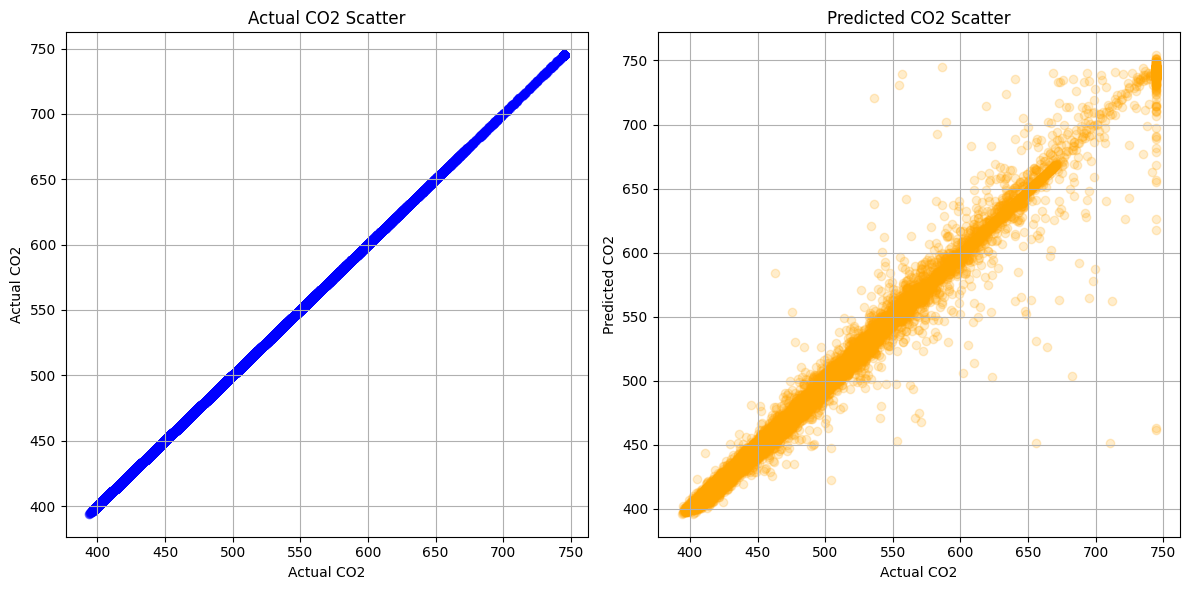

In [1]:
# Run the original N-BEATS notebook first.
# This keeps N_BEATS.ipynb unchanged and reuses its trained model and variables.
%run ./N_BEATS.ipynb


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

try:
    from captum.attr import IntegratedGradients
except ImportError as exc:
    raise ImportError(
        "Captum is required for Integrated Gradients. Install it with: pip install captum"
    ) from exc

model.eval()
print("Model ready for Integrated Gradients")

Model ready for Integrated Gradients


In [3]:
# Check that the variables created by N_BEATS.ipynb are available.
required_names = [
    "model",
    "X_test",
    "y_test",
    "feature_cols",
    "y_scaler",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise NameError(f"Missing variables from N_BEATS.ipynb: {missing}")

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Number of features:", len(feature_cols))
print("Features:", feature_cols)


X_test shape: (27737, 60, 8)
y_test shape: (27737,)
Number of features: 8
Features: ['station_id', 'ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2']


In [4]:
# Select one test sample to explain.
sample_index = 0

x_sample = torch.tensor(X_test[sample_index:sample_index + 1], dtype=torch.float32)
y_true_scaled = np.array(y_test[sample_index]).reshape(1, -1)

with torch.no_grad():
    y_pred_scaled = model(x_sample).detach().numpy()

y_true_original = y_scaler.inverse_transform(y_true_scaled)[0, 0]
y_pred_original = y_scaler.inverse_transform(y_pred_scaled)[0, 0]

print("Sample index:", sample_index)
print("True CO2 15 min ahead:", y_true_original)
print("Predicted CO2 15 min ahead:", y_pred_original)
print("Input window shape:", x_sample.shape)


Sample index: 0
True CO2 15 min ahead: 505.66666
Predicted CO2 15 min ahead: 484.8861
Input window shape: torch.Size([1, 60, 8])


In [5]:
# # Apply Integrated Gradients to the selected sample.
# ig = IntegratedGradients(model)

# # Baseline in scaled space. Zero means minimum value seen in training after MinMax scaling.
# baseline = torch.zeros_like(x_sample)

# attributions, approximation_delta = ig.attribute(
#     inputs=x_sample,
#     baselines=baseline,
#     target=0,
#     n_steps=50,
#     return_convergence_delta=True,
# )

# attributions_np = attributions.detach().cpu().numpy()[0]

# print("Attribution shape:", attributions_np.shape)
# print("Approximation delta:", approximation_delta.item())

# Apply Integrated Gradients to the selected sample.
ig = IntegratedGradients(model)

# Better baseline: average training window in scaled space
baseline_np = X_train.mean(axis=0, keepdims=True)
baseline = torch.tensor(baseline_np, dtype=torch.float32)

attributions, approximation_delta = ig.attribute(
    inputs=x_sample,
    baselines=baseline,
    target=0,
    n_steps=50,
    return_convergence_delta=True,
)

attributions_np = attributions.detach().cpu().numpy()[0]

print("Attribution shape:", attributions_np.shape)
print("Approximation delta:", approximation_delta.item())


Attribution shape: (60, 8)
Approximation delta: -3.910437226295471e-05


In [6]:
# Completeness check:
# Sum of attributions should approximately equal prediction difference
# between actual input and baseline.

with torch.no_grad():
    pred_input = model(x_sample)
    pred_baseline = model(baseline)

prediction_difference = (pred_input - pred_baseline).item()
sum_attributions = attributions.sum().item()

print("Prediction difference F(x) - F(baseline):", prediction_difference)
print("Sum of Integrated Gradients attributions:", sum_attributions)
print("Approximation delta:", approximation_delta.item())

Prediction difference F(x) - F(baseline): -0.05590999126434326
Sum of Integrated Gradients attributions: -0.055949095636606216
Approximation delta: -3.910437226295471e-05


In [7]:
# Local feature importance for this one prediction.
# We sum absolute attribution values across the 60 time steps.
local_feature_importance = np.abs(attributions_np).sum(axis=0)

local_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": local_feature_importance,
}).sort_values("importance", ascending=False).reset_index(drop=True)

local_importance_df


,feature,importance
0,scd41_co2,0.087581
1,ens160_tvoc,0.065207
2,bme688_pressure,0.045369
3,ens160_aqi,0.035952
4,scd41_temperature,0.023069
5,scd41_humidity,0.012321
6,bme688_gas_resistance,0.005116
7,station_id,0.004209


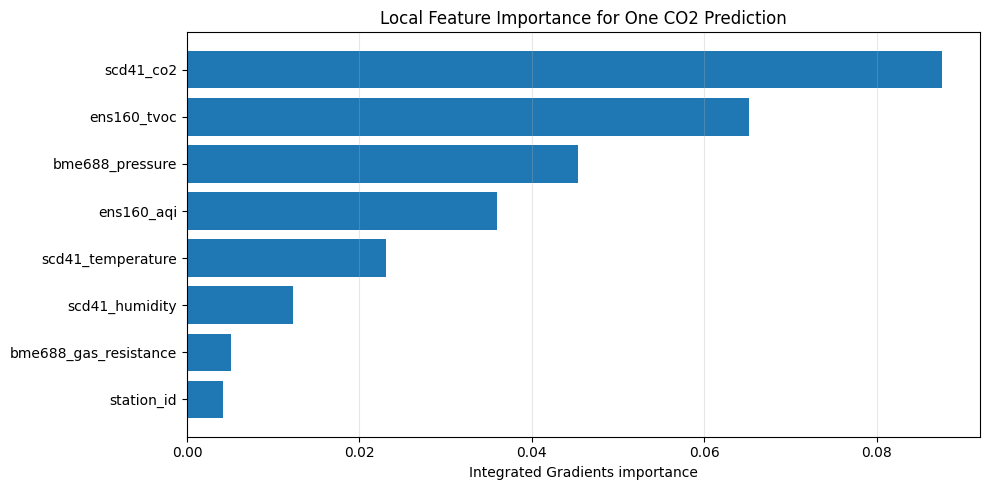

In [8]:
plt.figure(figsize=(10, 5))
plt.barh(local_importance_df["feature"], local_importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Integrated Gradients importance")
plt.title("Local Feature Importance for One CO2 Prediction")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


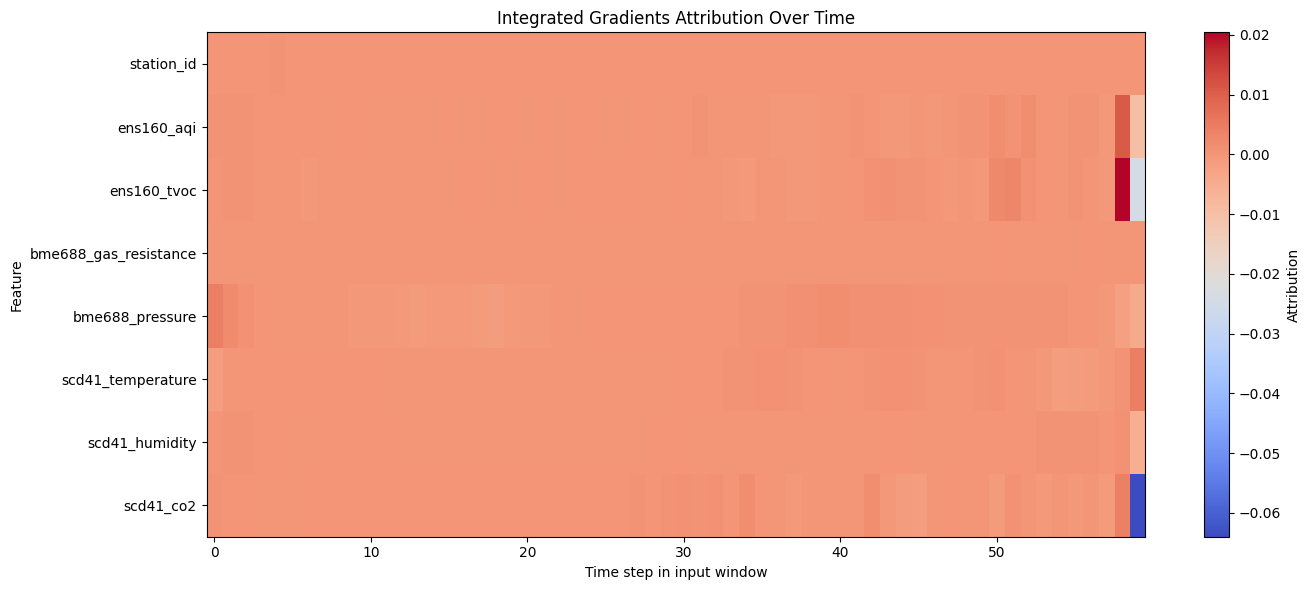

In [9]:
# Heatmap: feature contribution across the 60-step input window.
plt.figure(figsize=(14, 6))
plt.imshow(attributions_np.T, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Attribution")
plt.yticks(range(len(feature_cols)), feature_cols)
plt.xlabel("Time step in input window")
plt.ylabel("Feature")
plt.title("Integrated Gradients Attribution Over Time")
plt.tight_layout()
plt.show()


In [10]:
# Lag-wise / timestep-wise importance for one prediction.
# We sum absolute attribution values across all features.
lag_importance = np.abs(attributions_np).sum(axis=1)

lag_df = pd.DataFrame({
    "time_step": np.arange(1, len(lag_importance) + 1),
    "importance": lag_importance
})

lag_df.sort_values("importance", ascending=False).head(10)

,time_step,importance
59,60,0.112221
58,59,0.038531
0,1,0.007784
50,51,0.006274
51,52,0.004955
43,44,0.004438
44,45,0.004338
55,56,0.004005
42,43,0.003900
1,2,0.003711


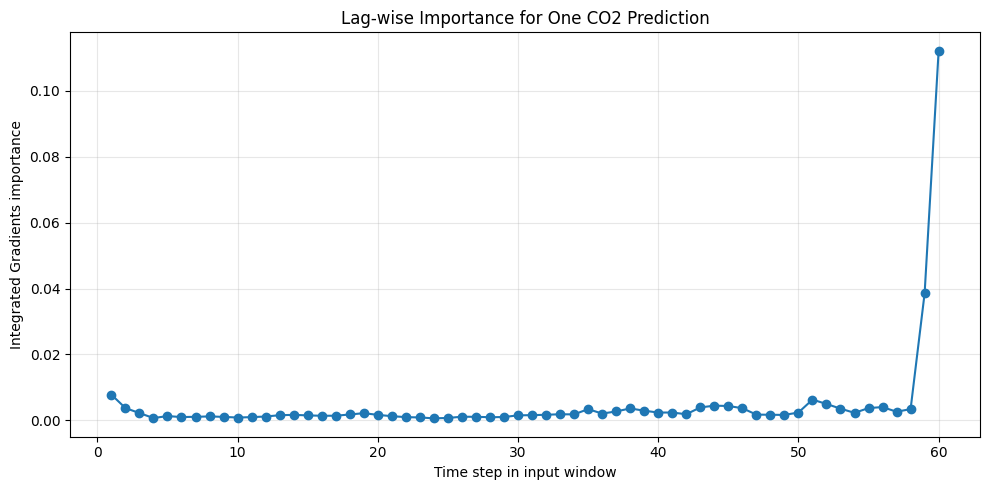

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(lag_df["time_step"], lag_df["importance"], marker="o")
plt.xlabel("Time step in input window")
plt.ylabel("Integrated Gradients importance")
plt.title("Lag-wise Importance for One CO2 Prediction")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# # Explain multiple test samples for a more global view.
# # Increase num_samples if you want, but larger values will take longer.
# num_samples = min(100, len(X_test))

# x_batch = torch.tensor(X_test[:num_samples], dtype=torch.float32)
# baseline_batch = torch.zeros_like(x_batch)

# batch_attributions = ig.attribute(
#     inputs=x_batch,
#     baselines=baseline_batch,
#     target=0,
#     n_steps=50,
# )

# batch_attr_np = batch_attributions.detach().cpu().numpy()
# print("Batch attribution shape:", batch_attr_np.shape)

# Explain multiple test samples for a more global view.
# Increase num_samples if you want, but larger values will take longer.
num_samples = min(100, len(X_test))

x_batch = torch.tensor(X_test[:num_samples], dtype=torch.float32)

# Mean training baseline repeated for each test sample
baseline_np = X_train.mean(axis=0, keepdims=True)
baseline_batch = torch.tensor(
    np.repeat(baseline_np, num_samples, axis=0),
    dtype=torch.float32
)

batch_attributions = ig.attribute(
    inputs=x_batch,
    baselines=baseline_batch,
    target=0,
    n_steps=50,
)

batch_attr_np = batch_attributions.detach().cpu().numpy()
print("Batch attribution shape:", batch_attr_np.shape)

Batch attribution shape: (100, 60, 8)


In [13]:
# Global feature importance across selected test samples.
global_feature_importance = np.abs(batch_attr_np).sum(axis=(0, 1))

global_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": global_feature_importance,
}).sort_values("importance", ascending=False).reset_index(drop=True)

global_importance_df


,feature,importance
0,scd41_co2,17.755798
1,bme688_pressure,4.461007
2,ens160_tvoc,2.566947
3,scd41_temperature,2.169019
4,ens160_aqi,2.023438
5,scd41_humidity,0.961595
6,bme688_gas_resistance,0.563201
7,station_id,0.153650


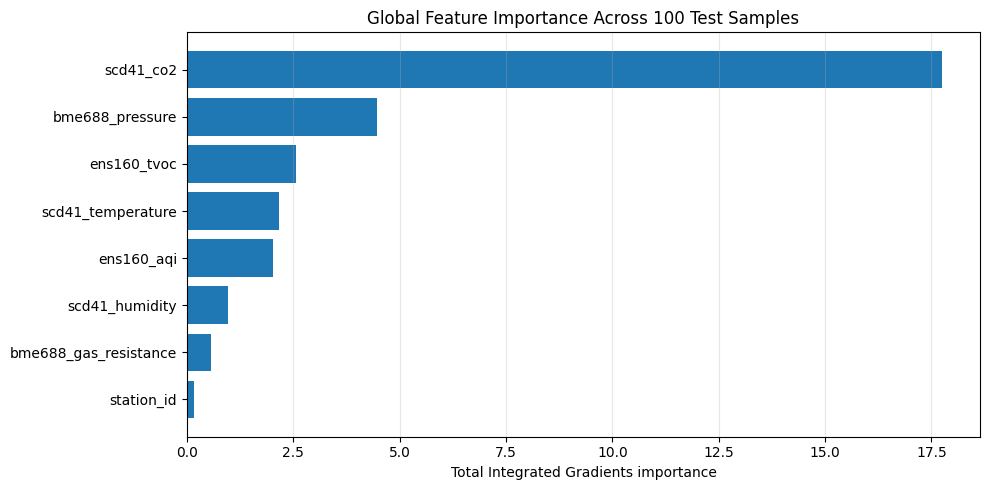

In [14]:
plt.figure(figsize=(10, 5))
plt.barh(global_importance_df["feature"], global_importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Total Integrated Gradients importance")
plt.title(f"Global Feature Importance Across {num_samples} Test Samples")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


In [15]:
# Global lag-wise importance across selected test samples.
global_lag_importance = np.abs(batch_attr_np).sum(axis=(0, 2))

global_lag_df = pd.DataFrame({
    "time_step": np.arange(1, len(global_lag_importance) + 1),
    "importance": global_lag_importance
})

global_lag_df.sort_values("importance", ascending=False).head(10)

,time_step,importance
59,60,17.308346
58,59,2.456075
0,1,0.889001
50,51,0.372384
57,58,0.355636
1,2,0.346152
44,45,0.320189
55,56,0.318615
43,44,0.310815
42,43,0.297735


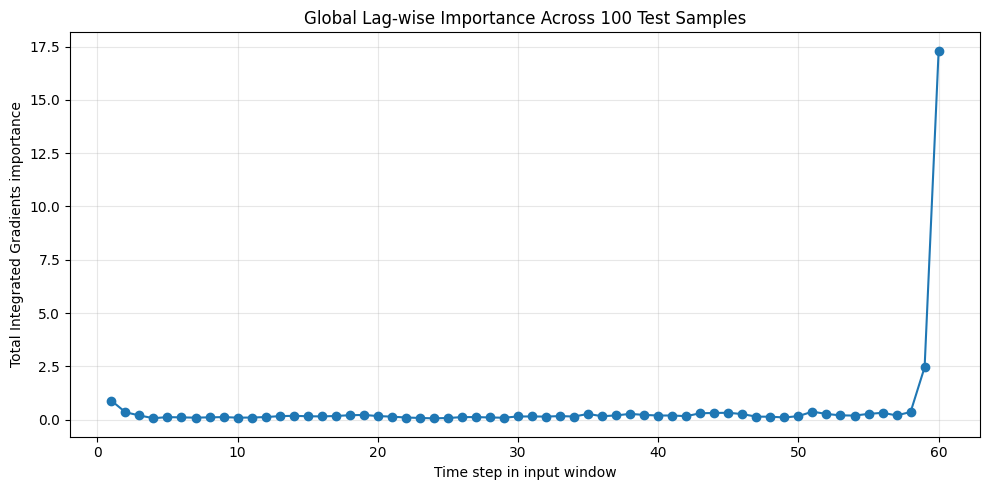

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(global_lag_df["time_step"], global_lag_df["importance"], marker="o")
plt.xlabel("Time step in input window")
plt.ylabel("Total Integrated Gradients importance")
plt.title(f"Global Lag-wise Importance Across {num_samples} Test Samples")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Optional: signed contribution per feature.
# Positive values push the prediction upward; negative values push it downward.
signed_feature_contribution = attributions_np.sum(axis=0)

signed_df = pd.DataFrame({
    "feature": feature_cols,
    "signed_contribution": signed_feature_contribution,
}).sort_values("signed_contribution", ascending=False).reset_index(drop=True)

signed_df


,feature,signed_contribution
0,bme688_pressure,0.006609
1,station_id,0.004209
2,ens160_aqi,0.001692
3,scd41_temperature,0.001282
4,ens160_tvoc,-0.001093
5,scd41_humidity,-0.003405
6,bme688_gas_resistance,-0.004999
7,scd41_co2,-0.060244


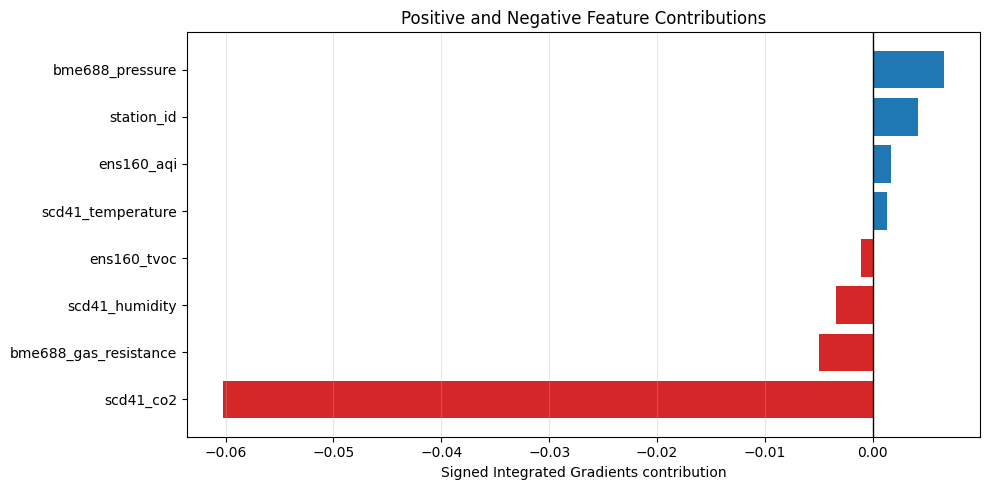

In [18]:
colors = ["tab:blue" if v >= 0 else "tab:red" for v in signed_df["signed_contribution"]]

plt.figure(figsize=(10, 5))
plt.barh(signed_df["feature"], signed_df["signed_contribution"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.gca().invert_yaxis()
plt.xlabel("Signed Integrated Gradients contribution")
plt.title("Positive and Negative Feature Contributions")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
